# 05 | Which assets deserve the next question?
**35 minutes · Applied portfolio screening and a short memo**

**By the end:** combine asset attributes with a spatial indicator; report coverage; test a decision rule; communicate an evidence gap.

**Scenario:** Your team has time for three initial operational interviews. Use the fictional heat screen to recommend questions and a shortlist. This is an educational triage exercise, not valuation or an estimated loss model.
This notebook runs independently using the bundled data; no previous notebook outputs are required.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the project root or a subfolder.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/assets.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Keep the notebooks and data folders together; open this project in Jupyter.')
DATA = ROOT / 'data'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})
print('Ready. Core lessons use bundled local data; no API key needed.')

Ready. Core lessons use bundled local data; no API key needed.


## 1. Separate hazard, exposure and vulnerability
**Hazard:** potentially harmful climate conditions. **Exposure:** assets or people in places affected. **Vulnerability:** how susceptible they are, including operational sensitivity and capacity to respond.
The [IPCC risk framework](https://www.ipcc.ch/site/assets/uploads/2021/01/The-concept-of-risk-in-the-IPCC-Sixth-Assessment-Report.pdf) connects these concepts. Our hot-day grid supplies only a simplified hazard-related indicator. Locations identify exposure; an unverified backup system is a question about vulnerability, not proof of failure.

Actual financial consequences also require evidence on operations, asset condition, contracts, insurance, adaptation and costs. We will not multiply a heat value by equity and call it loss.

In [2]:
import geopandas as gpd
import rasterio
assets = gpd.read_file(DATA / 'assets.geojson')
rows = []
with rasterio.open(DATA / 'synthetic_hot_days_2024.tif') as src:
    for asset in assets.to_crs(src.crs).itertuples():
        x,y = asset.geometry.x,asset.geometry.y
        inside = src.bounds.left <= x < src.bounds.right and src.bounds.bottom < y <= src.bounds.top
        value, coverage = np.nan, 'outside grid'
        if inside:
            sampled = next(src.sample([(x,y)],masked=True))[0]
            if np.ma.is_masked(sampled) or not np.isfinite(sampled):
                coverage = 'missing cell'
            else:
                value, coverage = float(sampled), 'available'
        rows.append({'asset_id':asset.asset_id,'hot_days_2024':value,'coverage':coverage})
screen = pd.DataFrame(assets.drop(columns='geometry')).merge(pd.DataFrame(rows),on='asset_id',validate='one_to_one')
assert len(screen) == len(assets)
display(screen[['asset_id','sector','equity_usd_m','hot_days_2024','coverage','cooling_backup_verified']])

,asset_id,sector,equity_usd_m,hot_days_2024,coverage,cooling_backup_verified
0,A01,Logistics,20,116.0,available,False
1,A02,Housing,35,92.0,available,True
2,A03,Logistics,28,96.0,available,False
3,A04,Energy,18,109.0,available,True
4,A05,Housing,42,79.0,available,False
5,A06,Logistics,16,69.0,available,False
6,A07,Office,33,57.0,available,True
7,A08,Digital infrastructure,60,91.0,available,False
8,A09,Housing,25,53.0,available,True
9,A10,Logistics,22,75.0,available,False


## 2. State your rule before looking at the shortlist
Illustrative rule: send assets with **at least 90 hot days and no verified cooling backup** to an operations review. Send missing climate values to a separate data follow-up. The 90-day cutoff is an analyst's classroom choice, not a validated safety threshold.

“No verified backup” includes unknown documentation. It does not establish that a system is absent. “Below review rule” does not mean safe from climate hazards.

In [3]:
review_threshold_days = 90  # TRY: 60 or 120
def assign_review(table, threshold):
    result = table.copy()
    result['review'] = 'Below rule / backup verified'
    needs_review = (result.hot_days_2024 >= threshold) & ~result.cooling_backup_verified.astype(bool)
    result.loc[needs_review,'review'] = 'Operations follow-up'
    result.loc[result.hot_days_2024.isna(),'review'] = 'Data follow-up'
    return result

screen = assign_review(screen,review_threshold_days)
summary = screen.groupby('review').agg(assets=('asset_id','count'),equity_usd_m=('equity_usd_m','sum'))
summary['share_of_total_equity_pct'] = 100*summary.equity_usd_m/screen.equity_usd_m.sum()
display(summary.round(1))
assert summary.assets.sum() == len(screen)
assert np.isclose(summary.share_of_total_equity_pct.sum(),100)
covered = screen.hot_days_2024.notna()
print(f'Climate data covers {covered.sum()}/{len(screen)} assets and '
      f'{screen.loc[covered,"equity_usd_m"].sum()/screen.equity_usd_m.sum():.1%} of total equity.')

,assets,equity_usd_m,share_of_total_equity_pct
review,,,
Below rule / backup verified,7,191,56.0
Data follow-up,2,42,12.3
Operations follow-up,3,108,31.7


Climate data covers 10/12 assets and 87.7% of total equity.


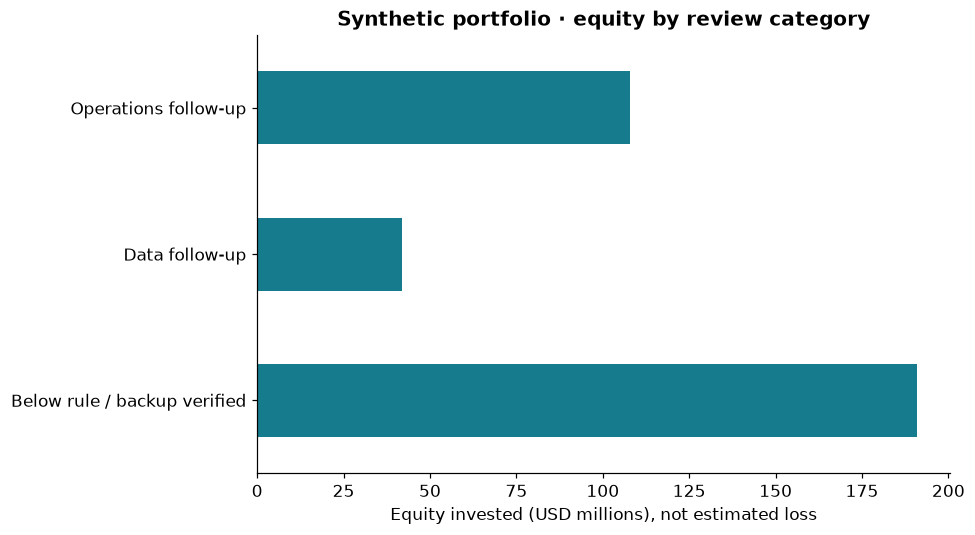

,asset_id,asset_name,hot_days_2024,equity_usd_m
0,A01,Bay warehouse,116.0,20
2,A03,Cedar logistics,96.0,28
7,A08,Harbor data center,91.0,60


In [4]:
fig, ax = plt.subplots()
summary.equity_usd_m.plot.barh(ax=ax,color='#167b8d')
ax.set(title='Synthetic portfolio · equity by review category',
       xlabel='Equity invested (USD millions), not estimated loss',ylabel='')
plt.tight_layout()
plt.show()

shortlist = screen.loc[screen.review == 'Operations follow-up'].sort_values(
    ['hot_days_2024','equity_usd_m'],ascending=False).head(3)
display(shortlist[['asset_id','asset_name','hot_days_2024','equity_usd_m']])

## 3. How much does the answer depend on our rule?
Change the days cutoff while keeping the ≥35°C hot-day definition fixed. These are two different thresholds: one defines a hot day, the other defines our review rule.
Ranking by hot days first and equity second is another classroom choice. A small critical facility might warrant more attention than a large less-sensitive property.

In [5]:
sensitivity = []
for cutoff in [60,90,120]:
    variant = assign_review(screen,cutoff)
    follow = variant.review == 'Operations follow-up'
    sensitivity.append({'review_cutoff_days':cutoff,'assets_for_operations':int(follow.sum()),
                        'equity_for_operations_usd_m':variant.loc[follow,'equity_usd_m'].sum(),
                        'unknown_assets':int(variant.hot_days_2024.isna().sum())})
display(pd.DataFrame(sensitivity))
screen.to_csv(OUT / 'synthetic_portfolio_screen.csv',index=False)
print('Saved outputs/synthetic_portfolio_screen.csv')

,review_cutoff_days,assets_for_operations,equity_for_operations_usd_m,unknown_assets
0,60,6,188,2
1,90,3,108,2
2,120,0,0,2


Saved outputs/synthetic_portfolio_screen.csv


## Your investment-team memo · 8 minutes
Write **120–180 words**. Address:

1. **Finding:** Which assets would you interview first, using the stated rule?
2. **Evidence:** Report count and equity coverage; distinguish the full-portfolio denominator from the covered subset.
3. **Limitation:** Explain the synthetic data, grid resolution, single-year indicator and arbitrary threshold.
4. **Next questions:** Request two pieces of asset-level evidence before estimating financial effects.

Do not conclude “safe,” “uninsurable,” or “expected loss” from this screen.

**Discuss:** If a site lacks climate data, should it receive less attention or a different kind of attention?

**Coding extension:** implement an alternative screening function and compare its selected asset IDs with the original rule. Assert that unknown assets remain in data follow-up and total equity is unchanged. Propose a sector-specific rule or multi-year metric and state what evidence would justify it.

**Takeaway:** a useful screen makes the next question more specific and makes uncertainty visible.